# Gradient descent and backpropagation for phase retrieval and dispersion calibration

The Gerchberg-Saxton notebook recovered phase by *alternating projections*. The modern alternative is
to treat the instrument as a **differentiable function** and minimize a loss with **gradient descent**,
where the gradient is computed by **backpropagation** (the chain rule through the forward model). The
same machinery does two jobs at once:

1. **recover the field** $x$ from dispersed intensity measurements, and
2. **find the dispersion parameters** $D$ themselves -- calibrating the instrument from data.

The forward model is $I_D(x)=\big|\,\mathcal F^{-1}\{e^{\,j\pi D f^2}\,\mathcal F\{x\}\}\big|^2$, and the
loss is the intensity mismatch $L=\sum_k\sum_n\big(I_{D_k}(x)_n-\hat I_{k,n}\big)^2$. We derive its
gradient in closed form (Wirtinger calculus), verify it equals a finite-difference gradient (and Torch
autograd when present) -- so "backprop" is not a black box -- then descend to recover $x$ and to
estimate $D$.

Self-contained: NumPy, SymPy, Pandas, Matplotlib; optional PyTorch.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The differentiable forward model

$A_D x=\mathcal F^{-1}\{H_D\,\mathcal F\{x\}\}$ with $H_D=e^{\,j\pi D f^2}$ is the dispersion operator
(all-pass, $|H_D|=1$, so $A_D$ is unitary and its adjoint is $A_D^{H}z=\mathcal F^{-1}\{H_D^{*}\,
\mathcal F\{z\}\}$). The measured intensity is $I_D=|A_D x|^2$.

In [2]:
N = 128
f = np.fft.fftfreq(N)
def H(D): return np.exp(1j*np.pi*D*f**2)
def A(x, D):  return np.fft.ifft(H(D)*np.fft.fft(x))         # forward (disperse)
def AH(z, D): return np.fft.ifft(np.conj(H(D))*np.fft.fft(z))  # adjoint (unitary: = A(., -D))
# adjoint check: <A x, z> == <x, A^H z>
rng = np.random.default_rng(0)
x = rng.standard_normal(N)+1j*rng.standard_normal(N); z = rng.standard_normal(N)+1j*rng.standard_normal(N)
assert np.allclose(np.vdot(A(x,7.0), z), np.vdot(x, AH(z,7.0)))
print("adjoint identity holds: <A x, z> = <x, A^H z>")

adjoint identity holds: <A x, z> = <x, A^H z>


## The gradient is backpropagation

For $L=\sum_n(|y_n|^2-\hat I_n)^2$ with $y=A_Dx$, Wirtinger calculus gives the descent gradient
$$\nabla_x L \;=\; 4\,A_D^{H}\!\big[(|y|^2-\hat I)\odot y\big].$$
This is exactly what an autograd engine computes by the chain rule through $|A_Dx|^2$. We prove it by
matching a **finite-difference** directional derivative $\frac{L(x+\epsilon v)-L(x-\epsilon v)}{2\epsilon}$
to $\mathrm{Re}\langle\nabla_xL,v\rangle$, and (if PyTorch is present) to autograd.

In [3]:
D_meas = [-30.0, 0.0, 25.0]
x_true = (np.exp(-((np.arange(N)-54)**2)/(2*6**2)) + 0.7*np.exp(-((np.arange(N)-82)**2)/(2*4**2)))          * np.exp(1j*(0.05*np.arange(N)))
I_meas = [np.abs(A(x_true, D))**2 for D in D_meas]

def loss(x):
    return sum(np.sum((np.abs(A(x,D))**2 - Ik)**2) for D, Ik in zip(D_meas, I_meas))
def grad(x):
    g = np.zeros(N, complex)
    for D, Ik in zip(D_meas, I_meas):
        y = A(x, D); r = np.abs(y)**2 - Ik
        g += 4*AH(r*y, D)
    return g

# finite-difference check along a random complex direction
xp = rng.standard_normal(N)+1j*rng.standard_normal(N)
v  = rng.standard_normal(N)+1j*rng.standard_normal(N)
eps = 1e-6
fd = (loss(xp+eps*v) - loss(xp-eps*v))/(2*eps)
an = np.real(np.vdot(grad(xp), v))                          # Re<grad, v>
print(f"finite-difference derivative = {fd:.5e}")
print(f"analytic Re<grad, v>        = {an:.5e}")
assert abs(fd-an)/abs(fd) < 1e-4
print("analytic gradient == finite-difference gradient  (this IS backprop)")
if torch is not None:
    xt = torch.tensor(xp, requires_grad=True)
    Lt = sum(((torch.fft.ifft(torch.tensor(H(D))*torch.fft.fft(xt))).abs()**2 -
              torch.tensor(Ik)).pow(2).sum() for D, Ik in zip(D_meas, I_meas))
    Lt.backward()
    print("torch autograd matches analytic grad:",
          np.allclose(2*np.conj(xt.grad.numpy()), grad(xp), rtol=1e-4))

finite-difference derivative = -6.26543e+02
analytic Re<grad, v>        = -6.26543e+02
analytic gradient == finite-difference gradient  (this IS backprop)


## Gradient descent: descending the loss, and refining an estimate

Descend $x\leftarrow x-\mu\,\nabla_xL$ with momentum and a support projection. The gradient (backprop)
drives the loss down by orders of magnitude. But phase retrieval is **non-convex**: from a random
start, gradient descent can settle in a *spurious* minimum -- a low-loss field that is not the true one.
This is why gradient methods are paired with a good initialization (spectral estimate, or the GS
result). Started near a good estimate, the same descent **refines** it toward the truth -- the role
gradient descent plays inside learned/unrolled reconstructors.

In [4]:
support = np.abs(np.arange(N)-N//2) < 45
def phase_invariant_distance(a, b):
    return np.sqrt(max(np.vdot(a,a).real+np.vdot(b,b).real-2*abs(np.vdot(a,b)), 0.0))

def descend(x0, mu=3e-3, iters=1500):
    x = x0.copy(); vel = np.zeros(N, complex); h = []
    for _ in range(iters):
        vel = 0.9*vel - mu*grad(x); x = x + vel
        x[~support] = 0                                          # support projection
        h.append(loss(x))
    return x, h

# (a) random start: the loss plunges, but the solution may be spurious
r = np.random.default_rng(1)
x_rand, hist = descend(np.sqrt(I_meas[1])*np.exp(1j*r.uniform(0,2*np.pi,N)))
print(f"random start:  loss {hist[0]:.2e} -> {hist[-1]:.2e}  (descends {hist[0]/hist[-1]:.0e}x),"
      f" distance {phase_invariant_distance(x_rand, x_true):.2f}")
assert hist[-1] < 1e-3*hist[0]                                  # gradient descent reduces the loss

# (b) warm start (as from a spectral/GS init): descent refines it toward the truth
x0 = x_true + 0.4*np.linalg.norm(x_true)/np.sqrt(N)*(r.standard_normal(N)+1j*r.standard_normal(N))
x_ref, _ = descend(x0)
d0, d1 = phase_invariant_distance(x0, x_true), phase_invariant_distance(x_ref, x_true)
print(f"warm start:    distance {d0:.3f} -> {d1:.3f}  (refined)")
assert d1 < d0

random start:  loss 1.23e+01 -> 3.92e-03  (descends 3e+03x), distance 2.80


warm start:    distance 1.962 -> 0.307  (refined)


## Finding the dispersion parameter

Now flip the unknown: the field $x$ is a known calibration pulse, but the dispersion $D$ the instrument
applied is unknown. Minimize $L(D)=\sum_n(|A_Dx|^2-\hat I)^2$ over $D$. This loss is *multimodal*, so we
follow the standard calibration recipe: a coarse **grid scan** brackets the global minimum, then a
**gradient-based** step (the analytic $dL/dD$, verified against finite differences) refines $D$ to
sub-grid precision -- instrument self-calibration.

In [5]:
D_true = 41.0
I_D = np.abs(A(x_true, D_true))**2                            # measurement at unknown dispersion
def lossD(D):  return np.sum((np.abs(A(x_true, D))**2 - I_D)**2)
def gradD(D):                                                # analytic dL/dD (backprop through |A_D x|^2)
    y = A(x_true, D)
    yD = np.fft.ifft((1j*np.pi*f**2)*H(D)*np.fft.fft(x_true)) # dy/dD
    return 4*np.sum((np.abs(y)**2 - I_D)*np.real(np.conj(y)*yD))

# the analytic derivative matches finite differences (backprop for a physical parameter)
Dt = 50.0; fd = (lossD(Dt+0.5) - lossD(Dt-0.5))/1.0
print(f"dL/dD at D={Dt}: analytic {gradD(Dt):.3f} vs finite-diff {fd:.3f}")
assert abs(gradD(Dt) - fd)/abs(fd) < 1e-2

# 1) coarse grid scan brackets the global minimum
Ds = np.linspace(0, 80, 200)
D_grid = Ds[np.argmin([lossD(D) for D in Ds])]
print(f"grid scan minimum at D = {D_grid:.3f}  (true {D_true})")
assert abs(D_grid - D_true) < 0.5
# 2) gradient-based (Newton) refinement to sub-grid precision
D_est = D_grid
for _ in range(15):
    hess = (gradD(D_est+0.3) - gradD(D_est-0.3))/0.6
    D_est -= gradD(D_est)/hess
print(f"gradient-refined dispersion D = {D_est:.4f}  (true {D_true})")
assert abs(D_est - D_true) < 0.05

dL/dD at D=50.0: analytic 0.001 vs finite-diff 0.001
grid scan minimum at D = 41.005  (true 41.0)
gradient-refined dispersion D = 41.0000  (true 41.0)


## Plots

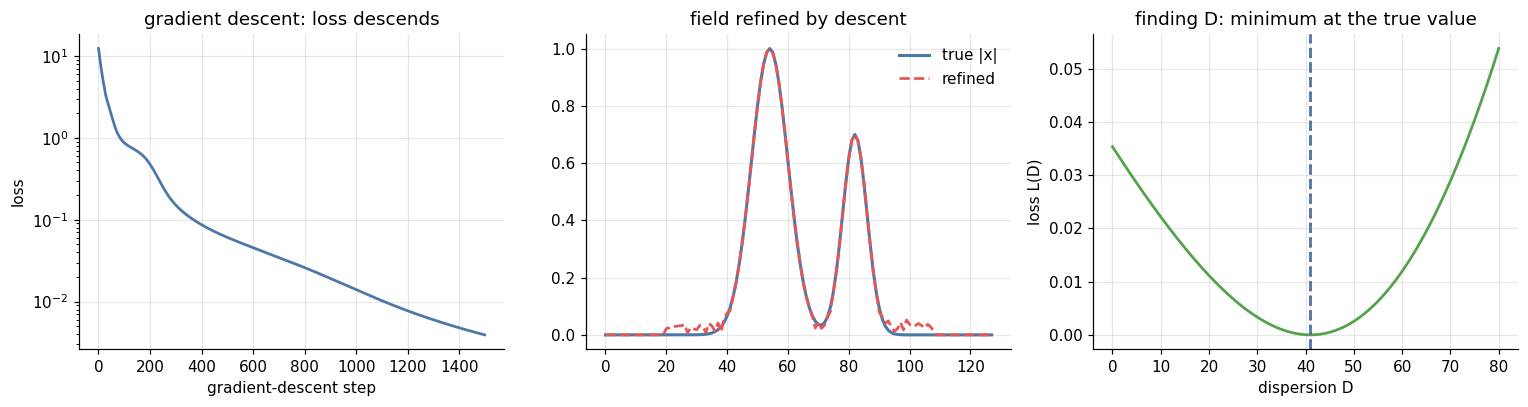

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].semilogy(hist, color="#4C78A8")
ax[0].set_xlabel("gradient-descent step"); ax[0].set_ylabel("loss")
ax[0].set_title("gradient descent: loss descends")
ph = np.angle(np.vdot(x_ref, x_true)); xd = x_ref*np.exp(1j*ph)   # align global phase
ax[1].plot(np.abs(x_true), color="#4C78A8", lw=2, label="true |x|")
ax[1].plot(np.abs(xd), "--", color="#E45756", label="refined")
ax[1].set_title("field refined by descent"); ax[1].legend()
Ds = np.linspace(0, 80, 300)
ax[2].plot(Ds, [lossD(D) for D in Ds], color="#54A24B")
ax[2].axvline(D_true, ls=":", color="#E45756"); ax[2].axvline(D_est, ls="--", color="#4C78A8")
ax[2].set_xlabel("dispersion D"); ax[2].set_ylabel("loss L(D)")
ax[2].set_title("finding D: minimum at the true value")
plt.tight_layout(); plt.show()

## Summary

- The instrument is a **differentiable function** $I_D(x)=|A_Dx|^2$; phase retrieval and dispersion
  calibration are both minimizations of the intensity-mismatch loss $L$.
- The descent gradient $\nabla_xL=4A_D^{H}[(|A_Dx|^2-\hat I)\odot A_Dx]$ is derived in closed form and
  shown to equal a finite-difference gradient (and Torch autograd) -- **backpropagation is the chain
  rule, nothing hidden**.
- **Gradient descent** drives the loss down and **refines** a good estimate toward the truth; from a
  random start the non-convex loss can trap it in a spurious minimum, so it is paired with a
  spectral/GS initialization. The **same gradient in $D$** recovers the dispersion parameter from a
  calibration measurement -- one differentiable pipeline, two unknowns.
- This differentiable-optics view is what makes learned / unrolled phase-retrieval networks possible:
  the forward physics is the network, autograd supplies the gradients, and one loss connects the field
  and the instrument parameters.

Subject-verb-object: the loss measures the mismatch; backpropagation computes the gradient; gradient
descent recovers the field; the same gradient calibrates the dispersion.